# Reducción de Dimensionalidad: Transformación Agrícola en México (2001-2023)

**Proyecto:** La Frontera que Avanza — Pérdida Forestal y Cambio Agrícola en México  
**Fuente de datos:** SIAP — Servicio de Información Agroalimentaria y Pesquera  
**Técnicas aplicadas:** PCA · LDA · t-SNE · UMAP · Isomap

---

## Contexto del dataset

Los datos provienen de los archivos SIAP que registran la superficie sembrada, cosechada y el valor de producción de ~260 cultivos distintos a nivel nacional, para los años 2001 y 2023.

### ¿Por qué tiene más de 4 dimensiones?

Cada cultivo es un punto en un espacio de **12 dimensiones**:

| # | Variable | Descripción |
|---|----------|-------------|
| 1 | `sembrada_2001` | Hectáreas sembradas en 2001 |
| 2 | `cosechada_2001` | Hectáreas cosechadas en 2001 |
| 3 | `valor_2001` | Valor de producción en 2001 (miles de pesos) |
| 4 | `sembrada_2023` | Hectáreas sembradas en 2023 |
| 5 | `cosechada_2023` | Hectáreas cosechadas en 2023 |
| 6 | `valor_2023` | Valor de producción en 2023 (miles de pesos) |
| 7 | `cambio_ha` | Cambio absoluto en hectáreas sembradas |
| 8 | `cambio_pct` | Cambio porcentual en hectáreas sembradas |
| 9 | `eficiencia_2001` | Ratio cosechada/sembrada en 2001 |
| 10 | `eficiencia_2023` | Ratio cosechada/sembrada en 2023 |
| 11 | `valor_por_ha_2001` | Valor por ha cosechada en 2001 |
| 12 | `valor_por_ha_2023` | Valor por ha cosechada en 2023 |

El objetivo es proyectar estos 12 dimensiones a 2D para identificar **grupos de cultivos** con comportamientos similares, y ver cuáles cultivos son los que más se asocian con la expansión de la frontera agrícola.

---
## 1. Importaciones y configuración

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE, Isomap
import umap

warnings.filterwarnings("ignore")

# Paleta del proyecto
PALETTE = {
    "expansion":   "#BC4749",  # cultivos que crecieron
    "retroceso":   "#2D6A4F",  # cultivos que retrocedieron
    "estable":     "#D4A017",  # cultivos estables
    "exportacion": "#8B0000",  # cultivos de exportacion clave
    "tradicional": "#1B4332",  # cultivos tradicionales clave
    "gris":        "#6B7B6D",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

SEED = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga y construcción del dataset

In [2]:
# Los archivos SIAP son HTML disfrazados de .xls
def cargar_siap(ruta, tipo):
    df = pd.read_html(ruta, encoding="utf-8")[0]
    df.columns = ["num", tipo, "sembrada", "cosechada", "valor"]
    df = df[~df[tipo].isin([tipo.capitalize(), "Total", "Entidad", "Cultivo"])]
    for c in ["sembrada", "cosechada", "valor"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=["sembrada"]).reset_index(drop=True)

DATA_DIR = "Data/DGSIAP"   # ajusta si tu ruta es distinta

c2001 = cargar_siap(f"{DATA_DIR}/2001_cultivo.xls", "cultivo")
c2023 = cargar_siap(f"{DATA_DIR}/2023_cultivo.xls", "cultivo")
e2001 = cargar_siap(f"{DATA_DIR}/2001_estados.xls", "estado")
e2023 = cargar_siap(f"{DATA_DIR}/2023_estados.xls", "estado")

print(f"Cultivos 2001: {len(c2001)}  |  Cultivos 2023: {len(c2023)}")
print(f"Estados 2001:  {len(e2001)}  |  Estados 2023:  {len(e2023)}")

Cultivos 2001: 252  |  Cultivos 2023: 261
Estados 2001:  32  |  Estados 2023:  32


In [3]:
# ── Dataset A: CULTIVOS (218 obs × 12 features) ─────────────────────────────
df_cult = c2001[["cultivo","sembrada","cosechada","valor"]].merge(
    c2023[["cultivo","sembrada","cosechada","valor"]],
    on="cultivo", suffixes=("_2001","_2023")
)
df_cult["cambio_ha"]          = df_cult["sembrada_2023"]  - df_cult["sembrada_2001"]
df_cult["cambio_pct"]         = df_cult["cambio_ha"] / df_cult["sembrada_2001"] * 100
df_cult["eficiencia_2001"]    = df_cult["cosechada_2001"] / df_cult["sembrada_2001"]
df_cult["eficiencia_2023"]    = df_cult["cosechada_2023"] / df_cult["sembrada_2023"]
df_cult["valor_por_ha_2001"]  = df_cult["valor_2001"]     / df_cult["cosechada_2001"]
df_cult["valor_por_ha_2023"]  = df_cult["valor_2023"]     / df_cult["cosechada_2023"]
df_cult = df_cult.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

FEATURES = [
    "sembrada_2001","cosechada_2001","valor_2001",
    "sembrada_2023","cosechada_2023","valor_2023",
    "cambio_ha","cambio_pct",
    "eficiencia_2001","eficiencia_2023",
    "valor_por_ha_2001","valor_por_ha_2023",
]

# ── Dataset B: ESTADOS (32 obs × 6 features) ────────────────────────────────
df_est = e2001[["estado","sembrada","cosechada","valor"]].merge(
    e2023[["estado","sembrada","cosechada","valor"]],
    on="estado", suffixes=("_2001","_2023")
)
df_est["cambio_ha"]  = df_est["sembrada_2023"] - df_est["sembrada_2001"]
df_est["cambio_pct"] = df_est["cambio_ha"] / df_est["sembrada_2001"] * 100
FEATURES_EST = ["sembrada_2001","cosechada_2001","valor_2001",
                "sembrada_2023","cosechada_2023","valor_2023"]

print(f"Dataset cultivos: {df_cult.shape}  →  {len(FEATURES)} dimensiones")
print(f"Dataset estados:  {df_est.shape}  →  {len(FEATURES_EST)} dimensiones")
print(f"\nPrimeras filas:")
df_cult[["cultivo"] + FEATURES[:6]].head()

Dataset cultivos: (218, 13)  →  12 dimensiones
Dataset estados:  (32, 9)  →  6 dimensiones

Primeras filas:


,cultivo,sembrada_2001,cosechada_2001,valor_2001,sembrada_2023,cosechada_2023,valor_2023
0,Aceituna,8386.00,4624.50,67797.07,5884.40,5249.40,356202.86
1,Acelga,1002.75,995.75,26071.80,757.72,757.72,56749.87
2,Achiote,765.00,354.50,2144.16,1166.00,912.50,22152.15
3,Agave,90066.29,6993.00,4505697.63,239271.06,33267.32,48284822.74
4,Aguacate,94477.13,94147.63,5030864.06,264589.06,253308.89,60097063.91


In [4]:
# ── Etiquetas para colorear ──────────────────────────────────────────────────
# Clasificamos cada cultivo según su trayectoria 2001-2023

CULTIVOS_EXPORTACION = [
    "Aguacate", "Agave", "Palma africana o de aceite",
    "Nuez", "Fresa", "Frambuesa", "Zarzamora", "Arandano",
]
CULTIVOS_TRADICIONALES = [
    "Maiz grano", "Frijol", "Sorgo grano", "Trigo grano",
    "Garbanzo grano", "Cartamo",
]
CULTIVOS_GANADEROS = [
    "Pastos y praderas", "Maiz forrajero en verde", "Alfalfa",
    "Avena forrajera en verde", "Sorgo forrajero en verde",
]

def clasificar(row):
    nombre = row["cultivo"]
    if nombre in CULTIVOS_EXPORTACION:
        return "Exportación"
    if nombre in CULTIVOS_TRADICIONALES:
        return "Tradicional"
    if nombre in CULTIVOS_GANADEROS:
        return "Ganadero/Forrajero"
    if row["cambio_pct"] > 50:
        return "Expansion alta"
    if row["cambio_pct"] < -30:
        return "Retroceso alto"
    return "Estable"

df_cult["categoria"] = df_cult.apply(clasificar, axis=1)
print("Distribución de categorías:")
print(df_cult["categoria"].value_counts().to_string())

# Paleta por categoría
CAT_COLORS = {
    "Exportación":         "#BC4749",
    "Tradicional":         "#1B4332",
    "Ganadero/Forrajero":  "#D4A017",
    "Expansion alta":      "#E07B54",
    "Retroceso alto":      "#52B788",
    "Estable":             "#A8BFC0",
}

colores_cult = df_cult["categoria"].map(CAT_COLORS)

# Para estados: región norte/sur
ESTADOS_SUR = [
    "Campeche","Chiapas","Guerrero","Oaxaca","Quintana Roo",
    "Tabasco","Veracruz","Yucatán","Chiapas"
]
df_est["region"] = df_est["estado"].apply(
    lambda x: "Sur/Trópico" if x in ESTADOS_SUR else "Norte/Centro"
)
colores_est = df_est["region"].map({"Sur/Trópico": "#BC4749", "Norte/Centro": "#2D6A4F"})

Distribución de categorías:
categoria
Estable               78
Expansion alta        77
Retroceso alto        48
Exportación            7
Ganadero/Forrajero     4
Tradicional            4


In [5]:
# ── Escalado ─────────────────────────────────────────────────────────────────
# Usamos RobustScaler: resiste mejor los outliers que StandardScaler,
# importante porque los cultivos varían en órdenes de magnitud (maíz vs. flor)

scaler = RobustScaler()
X = scaler.fit_transform(df_cult[FEATURES])
X_est = scaler.fit_transform(df_est[FEATURES_EST])

print(f"Matriz cultivos escalada: {X.shape}")
print(f"Matriz estados escalada:  {X_est.shape}")

# Etiqueta numérica para LDA
cat_map = {c: i for i, c in enumerate(df_cult["categoria"].unique())}
y_cat = df_cult["categoria"].map(cat_map).values
print(f"\nClases para LDA: {cat_map}")

Matriz cultivos escalada: (218, 12)
Matriz estados escalada:  (32, 6)

Clases para LDA: {'Estable': 0, 'Expansion alta': 1, 'Exportación': 2, 'Retroceso alto': 3, 'Ganadero/Forrajero': 4, 'Tradicional': 5}


---
## 3. PCA — Análisis de Componentes Principales

**¿Qué hace?**  
PCA encuentra las direcciones de **máxima varianza** en el espacio original y proyecta los datos sobre ellas. Es una transformación lineal: la PC1 captura la mayor variabilidad posible, la PC2 la segunda mayor ortogonal a la primera, y así.

**¿Por qué empezamos con PCA?**  
Es el punto de referencia. Al ver cuánta varianza acumulan las primeras 2 componentes sabremos qué tan bien se puede representar este dataset en 2D de forma lineal.

**Limitación:** Si las relaciones entre variables son no lineales (muy probable en datos agrícolas), PCA perderá esa estructura.

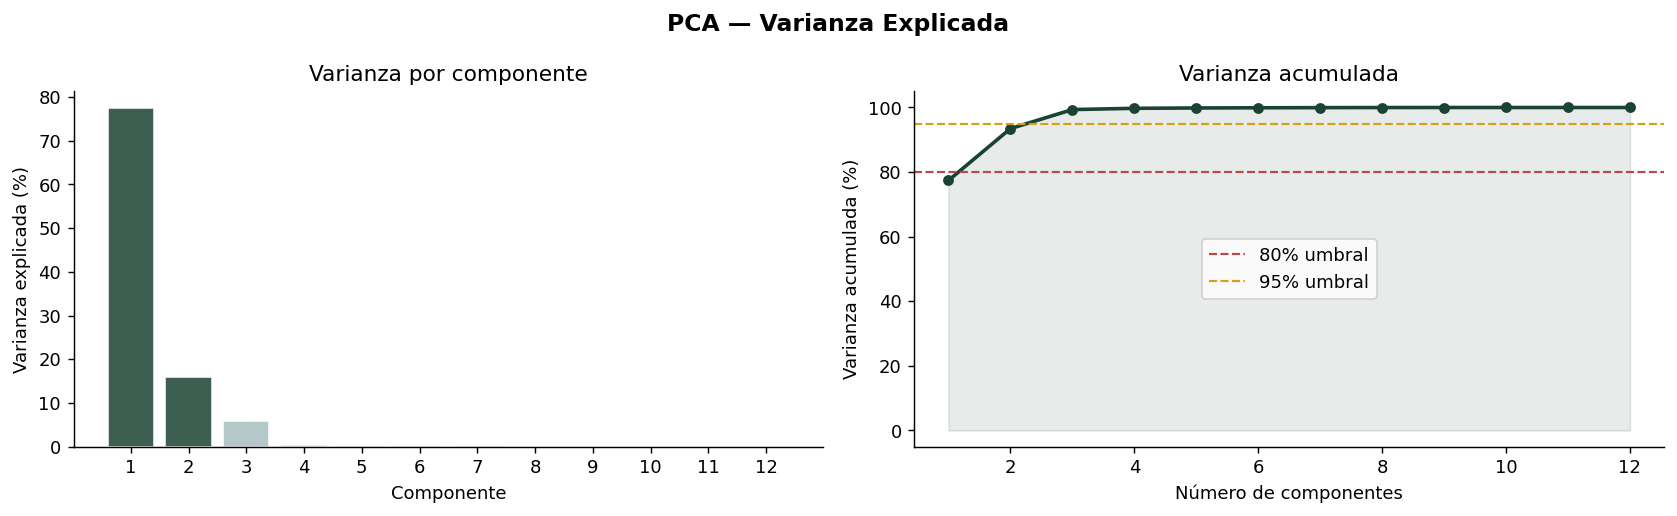

PC1+PC2 explican: 93.5% de la varianza
Componentes para 80% de varianza: 2
Componentes para 95% de varianza: 3


In [6]:
# ── PCA: Scree plot ───────────────────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)
n_comp = len(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA — Varianza Explicada", fontsize=13, fontweight="bold")

# Varianza por componente
ax = axes[0]
bars = ax.bar(range(1, n_comp+1), var_exp * 100,
              color=["#1B4332" if i < 2 else "#A8BFC0" for i in range(n_comp)],
              alpha=0.85, edgecolor="white")
ax.set_xlabel("Componente")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza por componente")
ax.set_xticks(range(1, n_comp+1))

# Varianza acumulada
ax2 = axes[1]
ax2.plot(range(1, n_comp+1), var_acum * 100, marker="o", color="#1B4332",
         linewidth=2, markersize=5)
ax2.axhline(80, color="#BC4749", linestyle="--", linewidth=1.2, label="80% umbral")
ax2.axhline(95, color="#D4A017", linestyle="--", linewidth=1.2, label="95% umbral")
ax2.fill_between(range(1, n_comp+1), var_acum * 100, alpha=0.1, color="#1B4332")
ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_title("Varianza acumulada")
ax2.legend()

plt.tight_layout()
plt.savefig("eda_output/DR_01_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

n80 = np.argmax(var_acum >= 0.80) + 1
n95 = np.argmax(var_acum >= 0.95) + 1
print(f"PC1+PC2 explican: {var_acum[1]*100:.1f}% de la varianza")
print(f"Componentes para 80% de varianza: {n80}")
print(f"Componentes para 95% de varianza: {n95}")

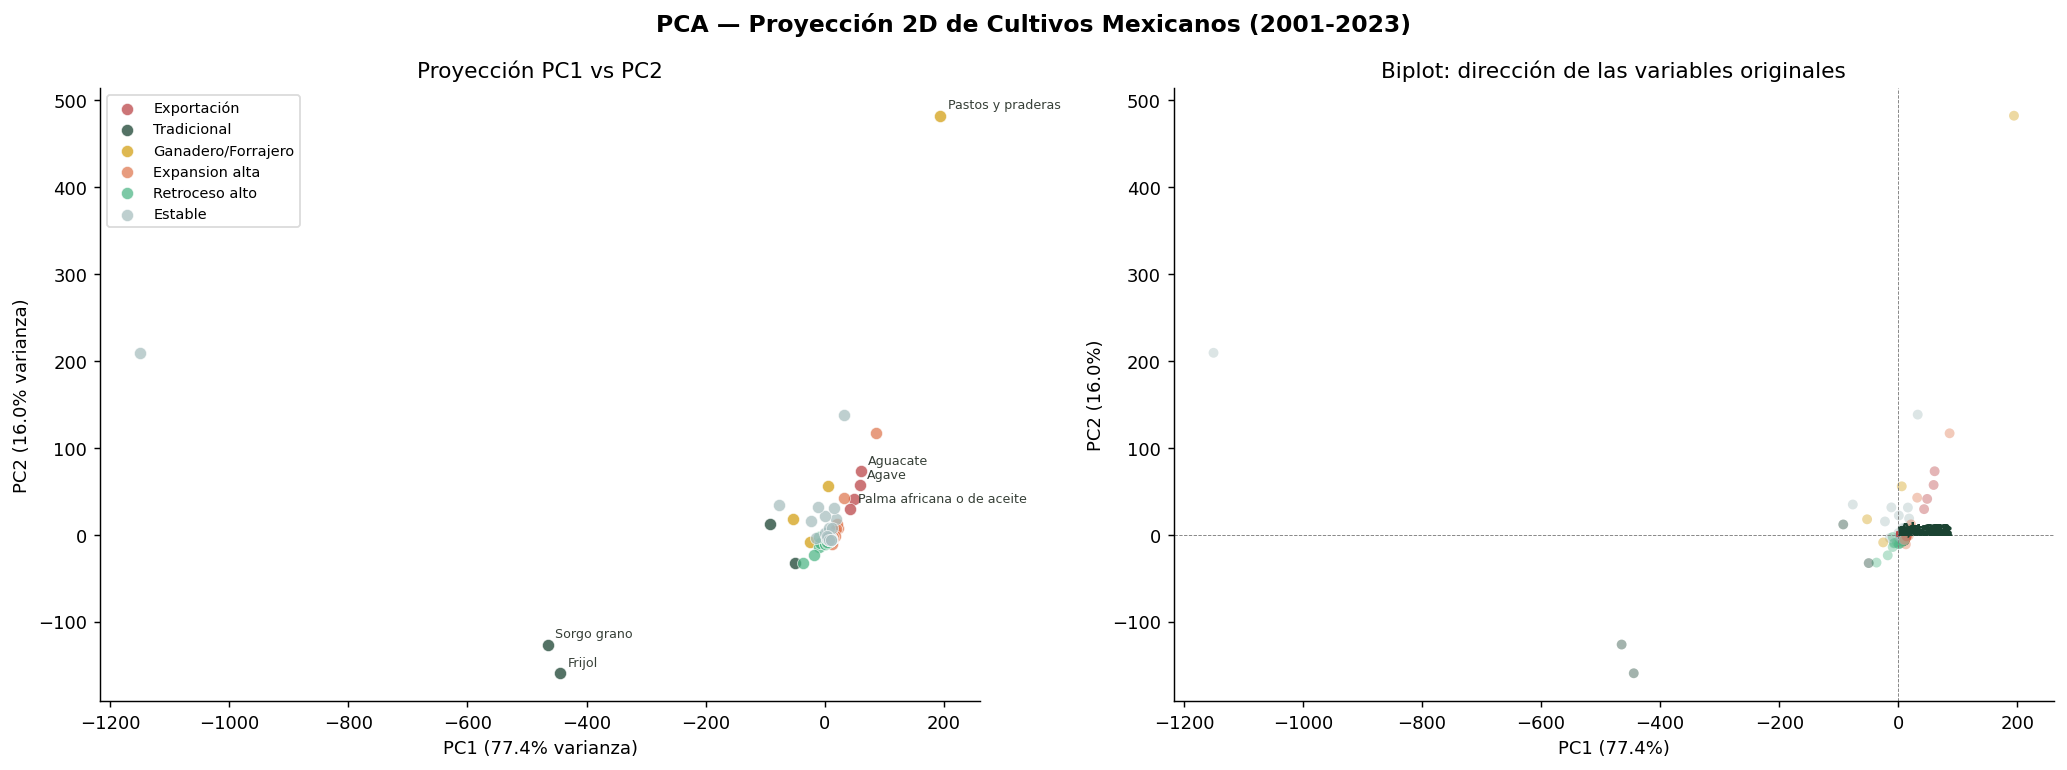

Varianza capturada en 2D: 93.5%

Loadings PC1 (variables con mayor peso):
      variable       PC1      PC2
     cambio_ha  0.765261 0.632999
cosechada_2001 -0.393491 0.392292
 sembrada_2001 -0.354563 0.337315
 sembrada_2023 -0.256623 0.388983
cosechada_2023 -0.236346 0.379144
    valor_2023 -0.079098 0.131225


In [7]:
# ── PCA: Proyección 2D y biplot ───────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA — Proyección 2D de Cultivos Mexicanos (2001-2023)",
             fontsize=13, fontweight="bold")

# Scatter por categoría
ax = axes[0]
for cat, color in CAT_COLORS.items():
    mask = df_cult["categoria"] == cat
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=cat, alpha=0.75, s=45, edgecolors="white", linewidth=0.4)

# Etiquetar cultivos clave
DESTACAR = ["Aguacate","Agave","Palma africana o de aceite",
            "Maiz grano","Frijol","Pastos y praderas","Sorgo grano"]
for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
    idx = row.name
    ax.annotate(row["cultivo"], (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=7, xytext=(4, 4), textcoords="offset points",
                color="#212B22", alpha=0.9)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza)")
ax.set_title("Proyección PC1 vs PC2")
ax.legend(fontsize=8, framealpha=0.7)

# Biplot: loadings de variables originales
ax2 = axes[1]
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=colores_cult, alpha=0.4, s=30,
            edgecolors="none")

loadings = pca2.components_.T
scale = 3.5
NOMBRES_CORTOS = [
    "sem01","cos01","val01",
    "sem23","cos23","val23",
    "Δha","Δ%",
    "efic01","efic23","v/ha01","v/ha23"
]
for i, (load, nombre) in enumerate(zip(loadings, NOMBRES_CORTOS)):
    ax2.arrow(0, 0, load[0]*scale, load[1]*scale,
              head_width=0.07, head_length=0.05,
              fc="#BC4749", ec="#BC4749", alpha=0.8, linewidth=1.5)
    ax2.text(load[0]*scale*1.12, load[1]*scale*1.12,
             nombre, fontsize=8, color="#1B4332", fontweight="bold")

ax2.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
ax2.set_title("Biplot: dirección de las variables originales")
ax2.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax2.axvline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("eda_output/DR_02_pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Varianza capturada en 2D: {var_acum[1]*100:.1f}%")
print("\nLoadings PC1 (variables con mayor peso):")
df_load = pd.DataFrame({"variable": FEATURES, "PC1": loadings[:,0], "PC2": loadings[:,1]})
print(df_load.sort_values("PC1", key=abs, ascending=False).head(6).to_string(index=False))

---
## 4. LDA — Análisis Discriminante Lineal

**¿Qué hace?**  
LDA es **supervisado**: usa las etiquetas de clase (las categorías de cultivo que definimos) para encontrar las proyecciones que **maximizan la separación entre clases** y minimizan la varianza dentro de cada clase.

**Diferencia clave con PCA:**  
- PCA ignora las etiquetas → busca máxima varianza total  
- LDA usa las etiquetas → busca máxima separación entre grupos  

**Limitación:** El número máximo de componentes discriminantes es `min(n_clases - 1, n_features)`. Con 6 clases, el máximo es 5 componentes.

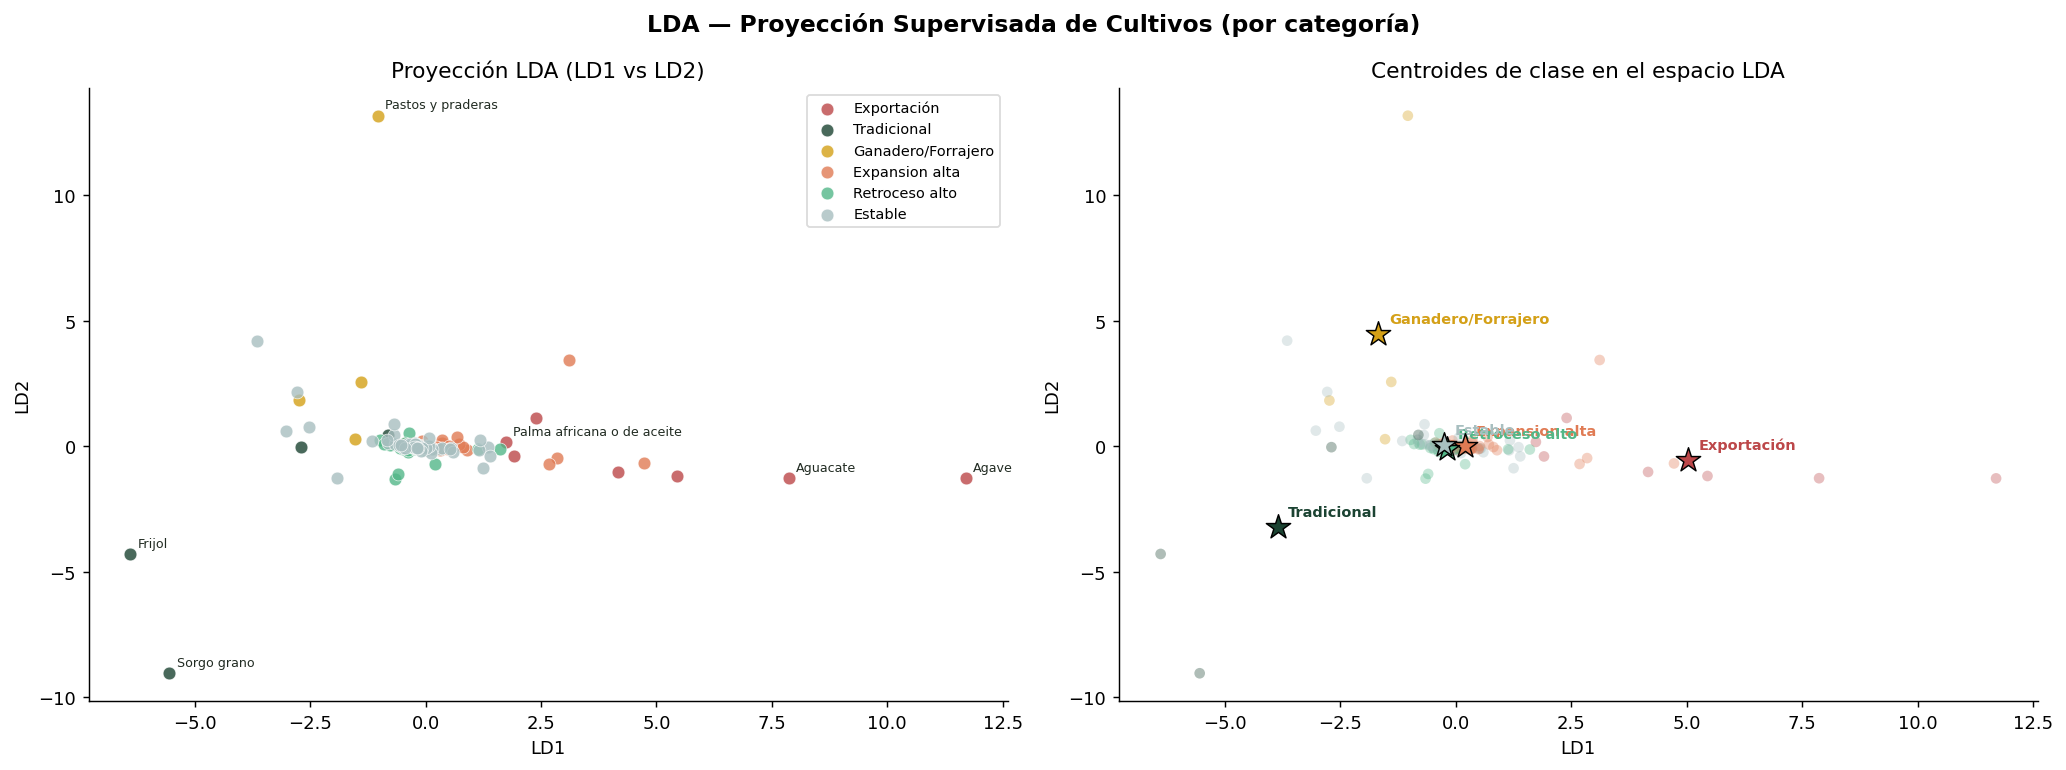

Varianza explicada por componente discriminante:
[0.5485 0.2639]


In [8]:
# ── LDA ───────────────────────────────────────────────────────────────────────
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("LDA — Proyección Supervisada de Cultivos (por categoría)",
             fontsize=13, fontweight="bold")

for ax_idx, (titulo, X_plot) in enumerate([
    ("LD1 vs LD2", X_lda),
]):
    ax = axes[0]
    for cat, color in CAT_COLORS.items():
        mask = df_cult["categoria"] == cat
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   c=color, label=cat, alpha=0.8, s=50,
                   edgecolors="white", linewidth=0.4)

    for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
        idx = row.name
        ax.annotate(row["cultivo"], (X_lda[idx, 0], X_lda[idx, 1]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points",
                    color="#212B22")

    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.set_title("Proyección LDA (LD1 vs LD2)")
    ax.legend(fontsize=8, framealpha=0.7)

# Panel 2: separación entre clases (centroides)
ax2 = axes[1]
ax2.scatter(X_lda[:, 0], X_lda[:, 1], c=colores_cult, alpha=0.35, s=35, edgecolors="none")

for cat, color in CAT_COLORS.items():
    mask = df_cult["categoria"].values == cat
    if mask.sum() == 0:
        continue
    cx, cy = X_lda[mask, 0].mean(), X_lda[mask, 1].mean()
    ax2.scatter(cx, cy, c=color, s=200, marker="*", zorder=5,
                edgecolors="black", linewidth=0.8)
    ax2.annotate(cat, (cx, cy), fontsize=8, fontweight="bold",
                 xytext=(6, 6), textcoords="offset points", color=color)

ax2.set_xlabel("LD1")
ax2.set_ylabel("LD2")
ax2.set_title("Centroides de clase en el espacio LDA")

plt.tight_layout()
plt.savefig("eda_output/DR_03_lda.png", dpi=150, bbox_inches="tight")
plt.show()

print("Varianza explicada por componente discriminante:")
print(lda.explained_variance_ratio_.round(4))

---
## 5. t-SNE — t-Distributed Stochastic Neighbor Embedding

**¿Qué hace?**  
t-SNE es un algoritmo **no lineal** que preserva las relaciones de **vecindad local**. Calcula probabilidades de que dos puntos sean "vecinos" en alta dimensión, y luego proyecta a 2D minimizando la diferencia entre esas distribuciones.

**Parámetro clave: `perplexity`**  
Controla cuántos vecinos considera "cercanos" cada punto. Un valor bajo (~5) captura estructura muy local; uno alto (~50) captura estructura más global. Probamos 3 valores.

**Limitaciones importantes:**  
- No preserva distancias globales (clusters cercanos en t-SNE no necesariamente lo son en el espacio original)
- No es determinista: dos corridas pueden dar layouts distintos
- Las escalas de los ejes no tienen interpretación directa

Ejecutando t-SNE con diferentes perplexity values...
  perplexity=5 → OK
  perplexity=20 → OK
  perplexity=40 → OK


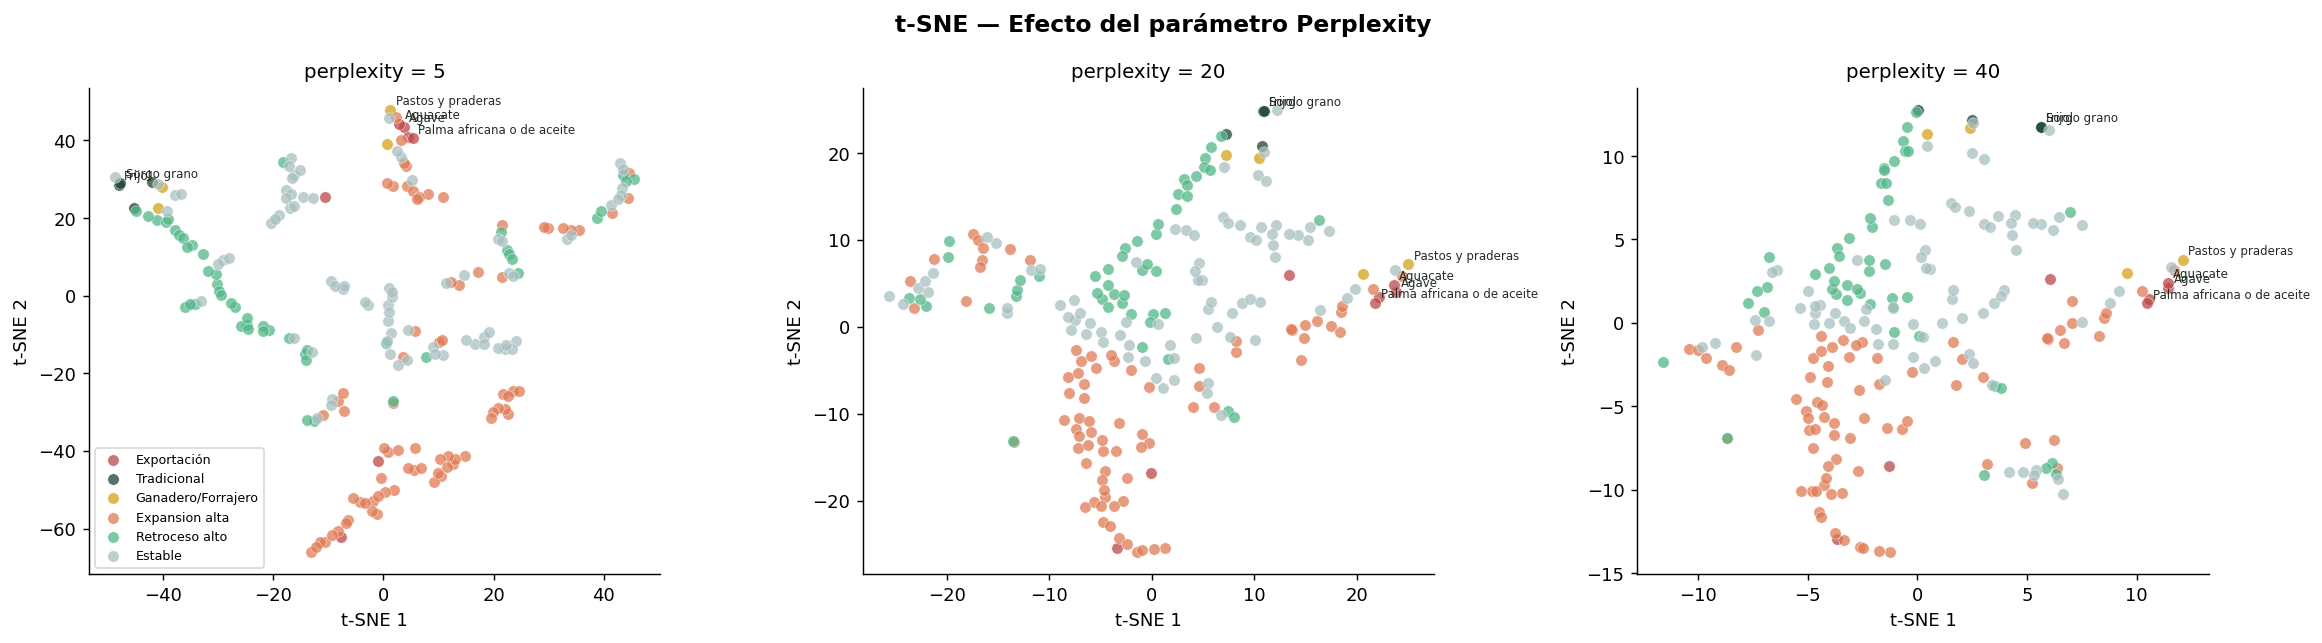

In [9]:
# ── t-SNE: exploración de perplexity ─────────────────────────────────────────
perplexities = [5, 20, 40]
resultados_tsne = {}

print("Ejecutando t-SNE con diferentes perplexity values...")
for p in perplexities:
    tsne = TSNE(n_components=2, perplexity=p, random_state=SEED,
                max_iter=1000, learning_rate="auto", init="pca")
    resultados_tsne[p] = tsne.fit_transform(X)
    print(f"  perplexity={p} → OK")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("t-SNE — Efecto del parámetro Perplexity",
             fontsize=13, fontweight="bold")

for ax, p in zip(axes, perplexities):
    X_tsne = resultados_tsne[p]
    for cat, color in CAT_COLORS.items():
        mask = df_cult["categoria"] == cat
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, label=cat, alpha=0.75, s=40,
                   edgecolors="white", linewidth=0.3)

    for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
        idx = row.name
        ax.annotate(row["cultivo"], (X_tsne[idx, 0], X_tsne[idx, 1]),
                    fontsize=6.5, xytext=(3, 3), textcoords="offset points",
                    color="#212B22")

    ax.set_title(f"perplexity = {p}", fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    if ax == axes[0]:
        ax.legend(fontsize=7, framealpha=0.7)

plt.tight_layout()
plt.savefig("eda_output/DR_04_tsne_perplexity.png", dpi=150, bbox_inches="tight")
plt.show()

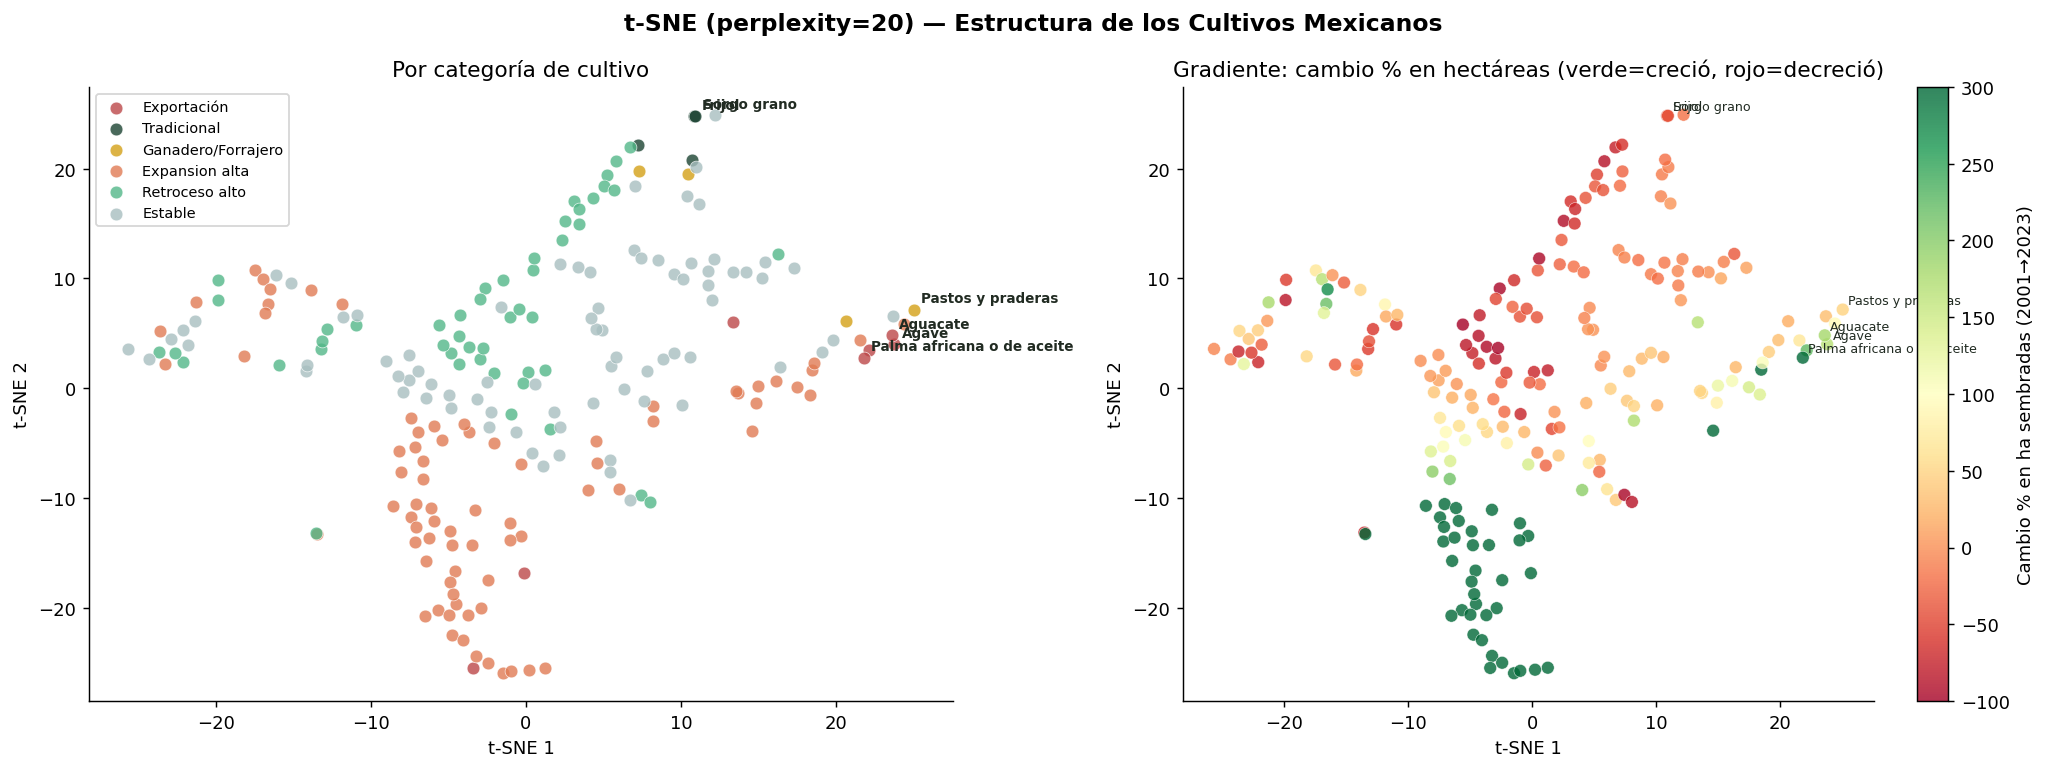

In [10]:
# ── t-SNE: mejor configuración (perplexity=20) ────────────────────────────────
X_tsne_best = resultados_tsne[20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("t-SNE (perplexity=20) — Estructura de los Cultivos Mexicanos",
             fontsize=13, fontweight="bold")

# Izq: por categoría
ax = axes[0]
for cat, color in CAT_COLORS.items():
    mask = df_cult["categoria"] == cat
    ax.scatter(X_tsne_best[mask, 0], X_tsne_best[mask, 1],
               c=color, label=cat, alpha=0.8, s=50,
               edgecolors="white", linewidth=0.4)
for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
    idx = row.name
    ax.annotate(row["cultivo"], (X_tsne_best[idx, 0], X_tsne_best[idx, 1]),
                fontsize=7.5, xytext=(4, 4), textcoords="offset points",
                color="#212B22", fontweight="bold")
ax.set_title("Por categoría de cultivo")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=8)

# Der: gradiente de cambio_pct
ax2 = axes[1]
cambio_clip = df_cult["cambio_pct"].clip(-100, 300)
sc = ax2.scatter(X_tsne_best[:, 0], X_tsne_best[:, 1],
                 c=cambio_clip, cmap="RdYlGn", vmin=-100, vmax=300,
                 alpha=0.8, s=50, edgecolors="white", linewidth=0.3)
plt.colorbar(sc, ax=ax2, label="Cambio % en ha sembradas (2001→2023)")
for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
    idx = row.name
    ax2.annotate(row["cultivo"], (X_tsne_best[idx, 0], X_tsne_best[idx, 1]),
                 fontsize=7, xytext=(3, 3), textcoords="offset points",
                 color="#212B22")
ax2.set_title("Gradiente: cambio % en hectáreas (verde=creció, rojo=decreció)")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig("eda_output/DR_05_tsne_best.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. UMAP — Uniform Manifold Approximation and Projection

**¿Qué hace?**  
UMAP construye un grafo de vecindad en alta dimensión y luego lo optimiza para preservar tanto la **estructura local** como la **estructura global**. Es más rápido que t-SNE y generalmente produce representaciones más informativas.

**Parámetros clave:**  
- `n_neighbors`: cuántos vecinos considera para construir el grafo. Valor bajo → más estructura local. Valor alto → más estructura global.
- `min_dist`: qué tan juntos pueden estar los puntos en la proyección. Valor bajo → clusters más compactos.

**Ventaja sobre t-SNE:** UMAP sí preserva algo de la estructura global, por lo que la distancia entre clusters tiene más sentido interpretativo.

Ejecutando UMAP con diferentes n_neighbors...
  n_neighbors=5 → OK
  n_neighbors=15 → OK
  n_neighbors=30 → OK


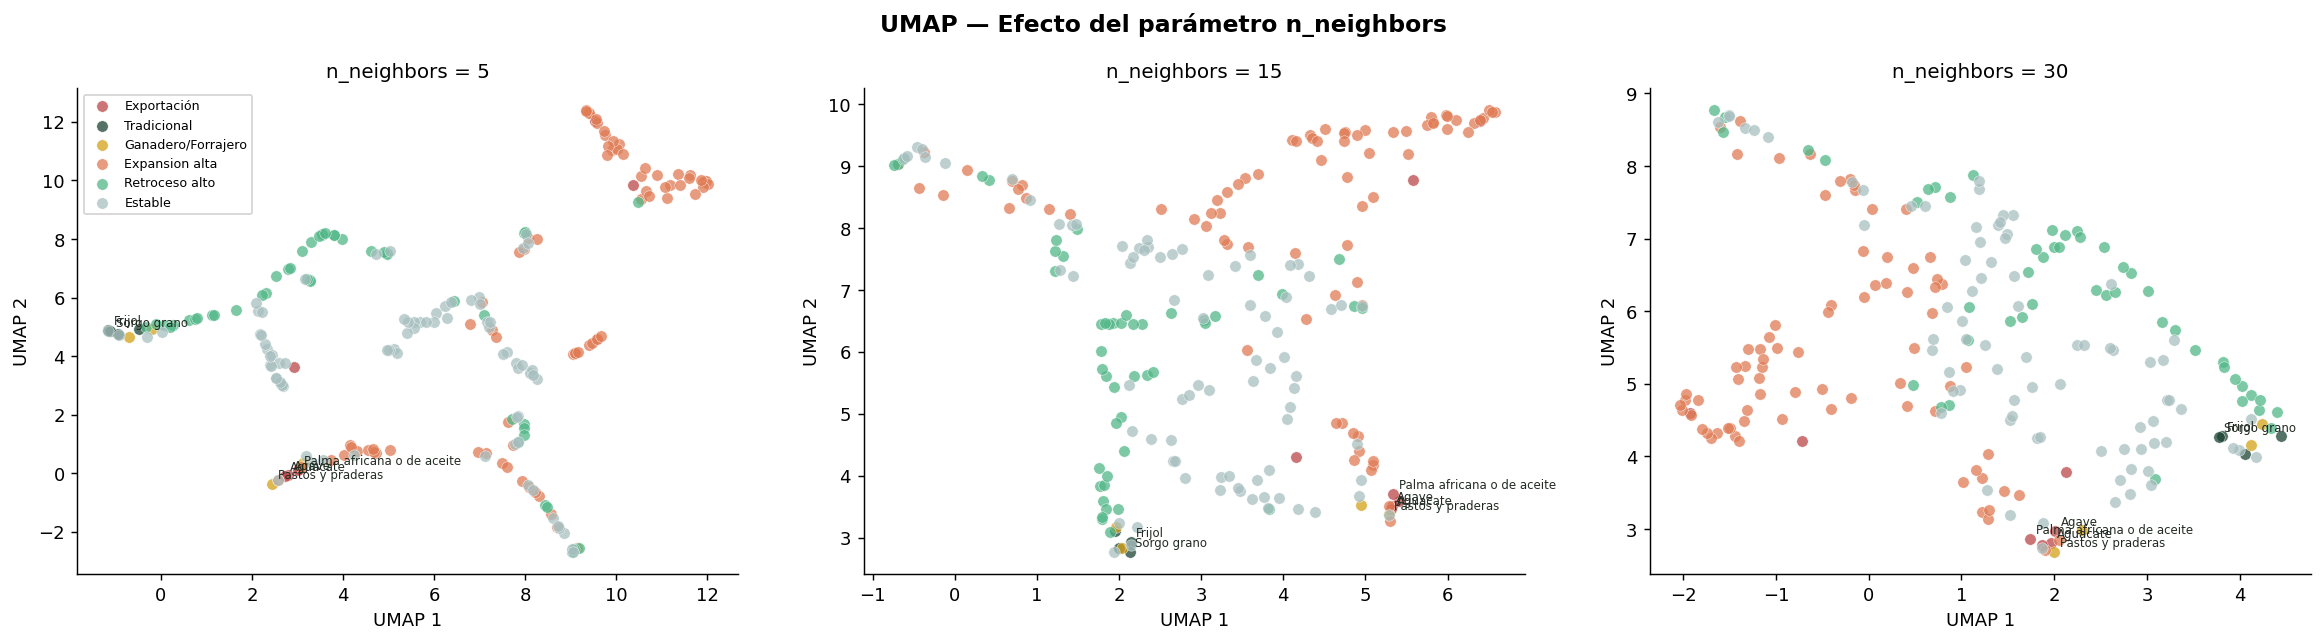

In [11]:
# ── UMAP: exploración de n_neighbors ─────────────────────────────────────────
neighbors_vals = [5, 15, 30]
resultados_umap = {}

print("Ejecutando UMAP con diferentes n_neighbors...")
for n in neighbors_vals:
    reducer = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=SEED, n_jobs=1)
    resultados_umap[n] = reducer.fit_transform(X)
    print(f"  n_neighbors={n} → OK")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UMAP — Efecto del parámetro n_neighbors",
             fontsize=13, fontweight="bold")

for ax, n in zip(axes, neighbors_vals):
    X_u = resultados_umap[n]
    for cat, color in CAT_COLORS.items():
        mask = df_cult["categoria"] == cat
        ax.scatter(X_u[mask, 0], X_u[mask, 1],
                   c=color, label=cat, alpha=0.75, s=40,
                   edgecolors="white", linewidth=0.3)
    for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
        idx = row.name
        ax.annotate(row["cultivo"], (X_u[idx, 0], X_u[idx, 1]),
                    fontsize=6.5, xytext=(3, 3), textcoords="offset points",
                    color="#212B22")
    ax.set_title(f"n_neighbors = {n}", fontsize=11)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_output/DR_06_umap_neighbors.png", dpi=150, bbox_inches="tight")
plt.show()

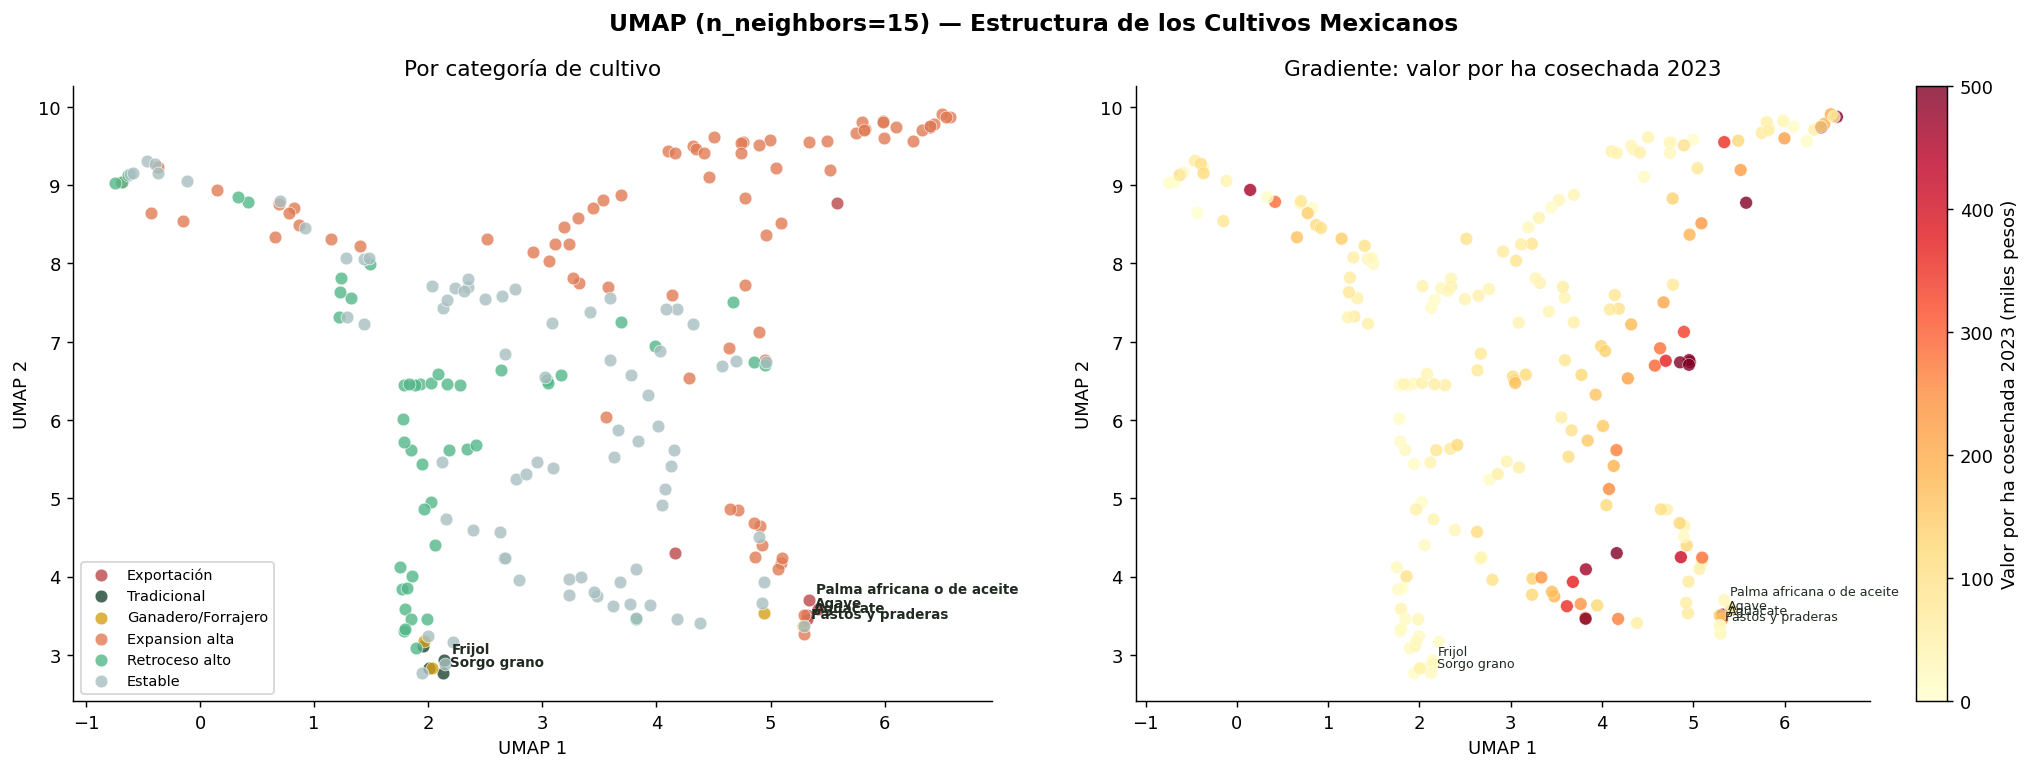

In [12]:
# ── UMAP: mejor configuración (n_neighbors=15) ────────────────────────────────
X_umap_best = resultados_umap[15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("UMAP (n_neighbors=15) — Estructura de los Cultivos Mexicanos",
             fontsize=13, fontweight="bold")

ax = axes[0]
for cat, color in CAT_COLORS.items():
    mask = df_cult["categoria"] == cat
    ax.scatter(X_umap_best[mask, 0], X_umap_best[mask, 1],
               c=color, label=cat, alpha=0.8, s=50,
               edgecolors="white", linewidth=0.4)
for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
    idx = row.name
    ax.annotate(row["cultivo"], (X_umap_best[idx, 0], X_umap_best[idx, 1]),
                fontsize=7.5, xytext=(4, 4), textcoords="offset points",
                color="#212B22", fontweight="bold")
ax.set_title("Por categoría de cultivo")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(fontsize=8)

# Gradiente de valor por ha
ax2 = axes[1]
val_clip = df_cult["valor_por_ha_2023"].clip(0, 500)
sc = ax2.scatter(X_umap_best[:, 0], X_umap_best[:, 1],
                 c=val_clip, cmap="YlOrRd", vmin=0, vmax=500,
                 alpha=0.8, s=50, edgecolors="white", linewidth=0.3)
plt.colorbar(sc, ax=ax2, label="Valor por ha cosechada 2023 (miles pesos)")
for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
    idx = row.name
    ax2.annotate(row["cultivo"], (X_umap_best[idx, 0], X_umap_best[idx, 1]),
                 fontsize=7, xytext=(3, 3), textcoords="offset points",
                 color="#212B22")
ax2.set_title("Gradiente: valor por ha cosechada 2023")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")

plt.tight_layout()
plt.savefig("eda_output/DR_07_umap_best.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Isomap — Isometric Mapping

**¿Qué hace?**  
Isomap extiende MDS (Multidimensional Scaling) para capturar la geometría **intrínseca no lineal** de los datos. Construye un grafo de vecinos y usa **distancias geodésicas** (sobre la "superficie" del manifiold) en lugar de distancias euclidianas directas.

**Diferencia clave:**  
Si los datos viven en una "curva" o "superficie" en el espacio de alta dimensión, Isomap desenrolla esa curva mejor que PCA. Es especialmente útil si hay relaciones no lineales continuas (como podrían ser trayectorias de crecimiento de cultivos).

**Parámetro clave:** `n_neighbors` — controla qué tan "local" es el grafo de vecindad.

Ejecutando Isomap...
  n_neighbors=5 → OK
  n_neighbors=10 → OK
  n_neighbors=20 → OK


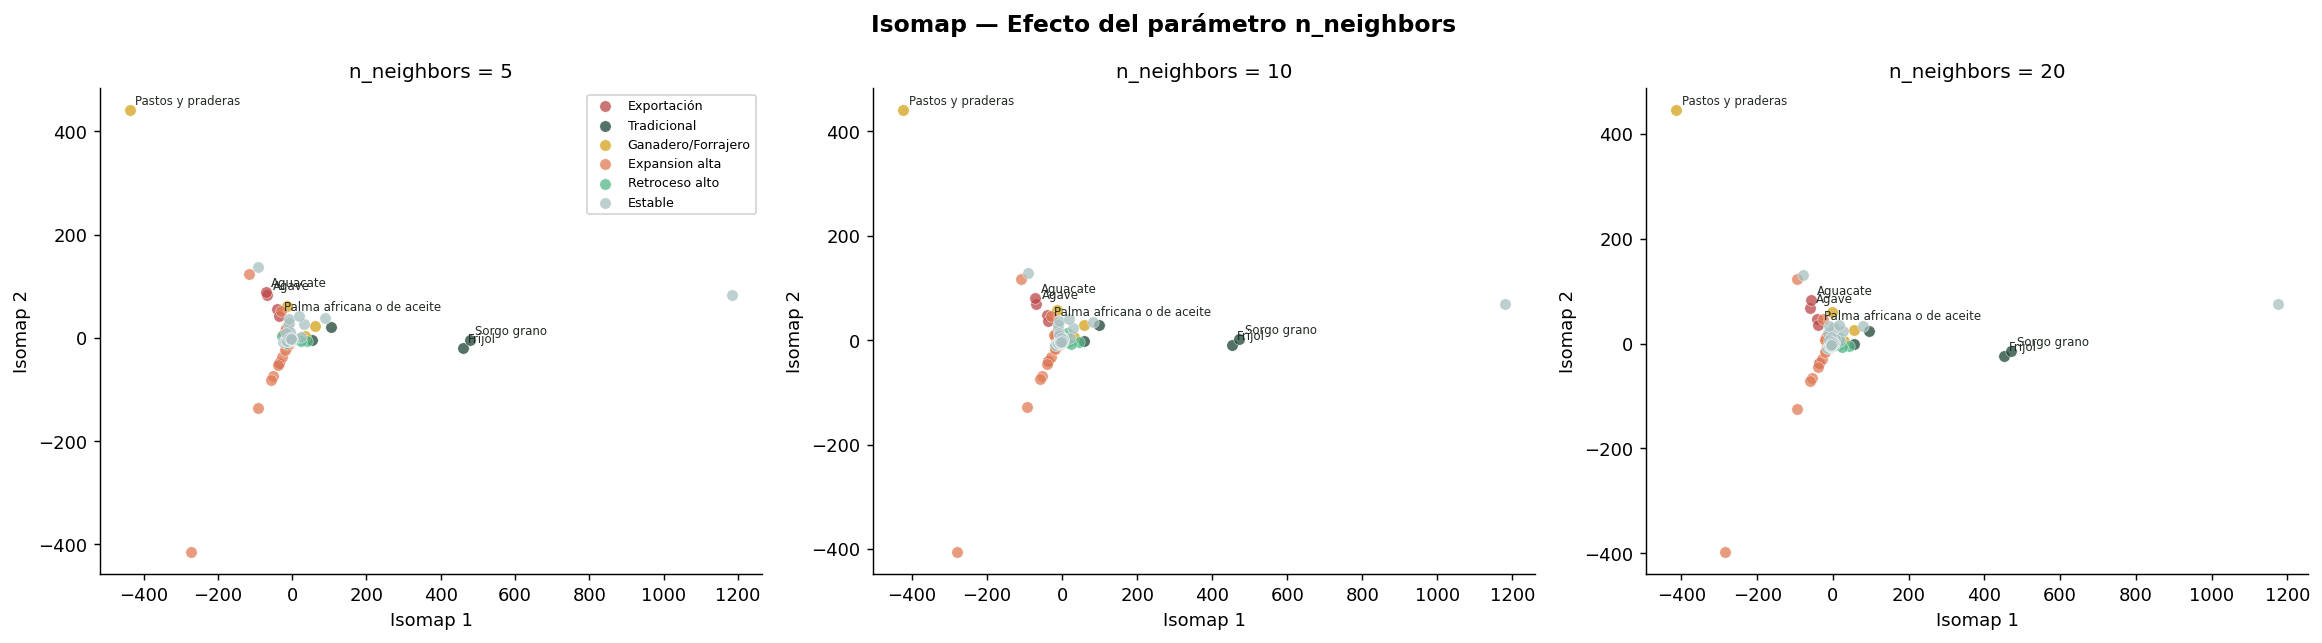

In [13]:
# ── Isomap ────────────────────────────────────────────────────────────────────
neighbors_iso = [5, 10, 20]
resultados_iso = {}

print("Ejecutando Isomap...")
for n in neighbors_iso:
    iso = Isomap(n_neighbors=n, n_components=2)
    resultados_iso[n] = iso.fit_transform(X)
    print(f"  n_neighbors={n} → OK")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Isomap — Efecto del parámetro n_neighbors",
             fontsize=13, fontweight="bold")

for ax, n in zip(axes, neighbors_iso):
    X_iso = resultados_iso[n]
    for cat, color in CAT_COLORS.items():
        mask = df_cult["categoria"] == cat
        ax.scatter(X_iso[mask, 0], X_iso[mask, 1],
                   c=color, label=cat, alpha=0.75, s=40,
                   edgecolors="white", linewidth=0.3)
    for _, row in df_cult[df_cult["cultivo"].isin(DESTACAR)].iterrows():
        idx = row.name
        ax.annotate(row["cultivo"], (X_iso[idx, 0], X_iso[idx, 1]),
                    fontsize=6.5, xytext=(3, 3), textcoords="offset points",
                    color="#212B22")
    ax.set_title(f"n_neighbors = {n}", fontsize=11)
    ax.set_xlabel("Isomap 1")
    ax.set_ylabel("Isomap 2")
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_output/DR_08_isomap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. PCA y UMAP sobre Estados (32 observaciones)

El dataset de cultivos tenía 218 observaciones × 12 dimensiones. Aquí cambiamos la perspectiva:
cada **estado** es un punto en un espacio de 6 dimensiones (sembrada, cosechada y valor en 2001 y 2023).

Con solo 32 estados, t-SNE e Isomap tienen poca utilidad (necesitan más puntos para construir relaciones de vecindad robustas). PCA y UMAP son más apropiados aquí.

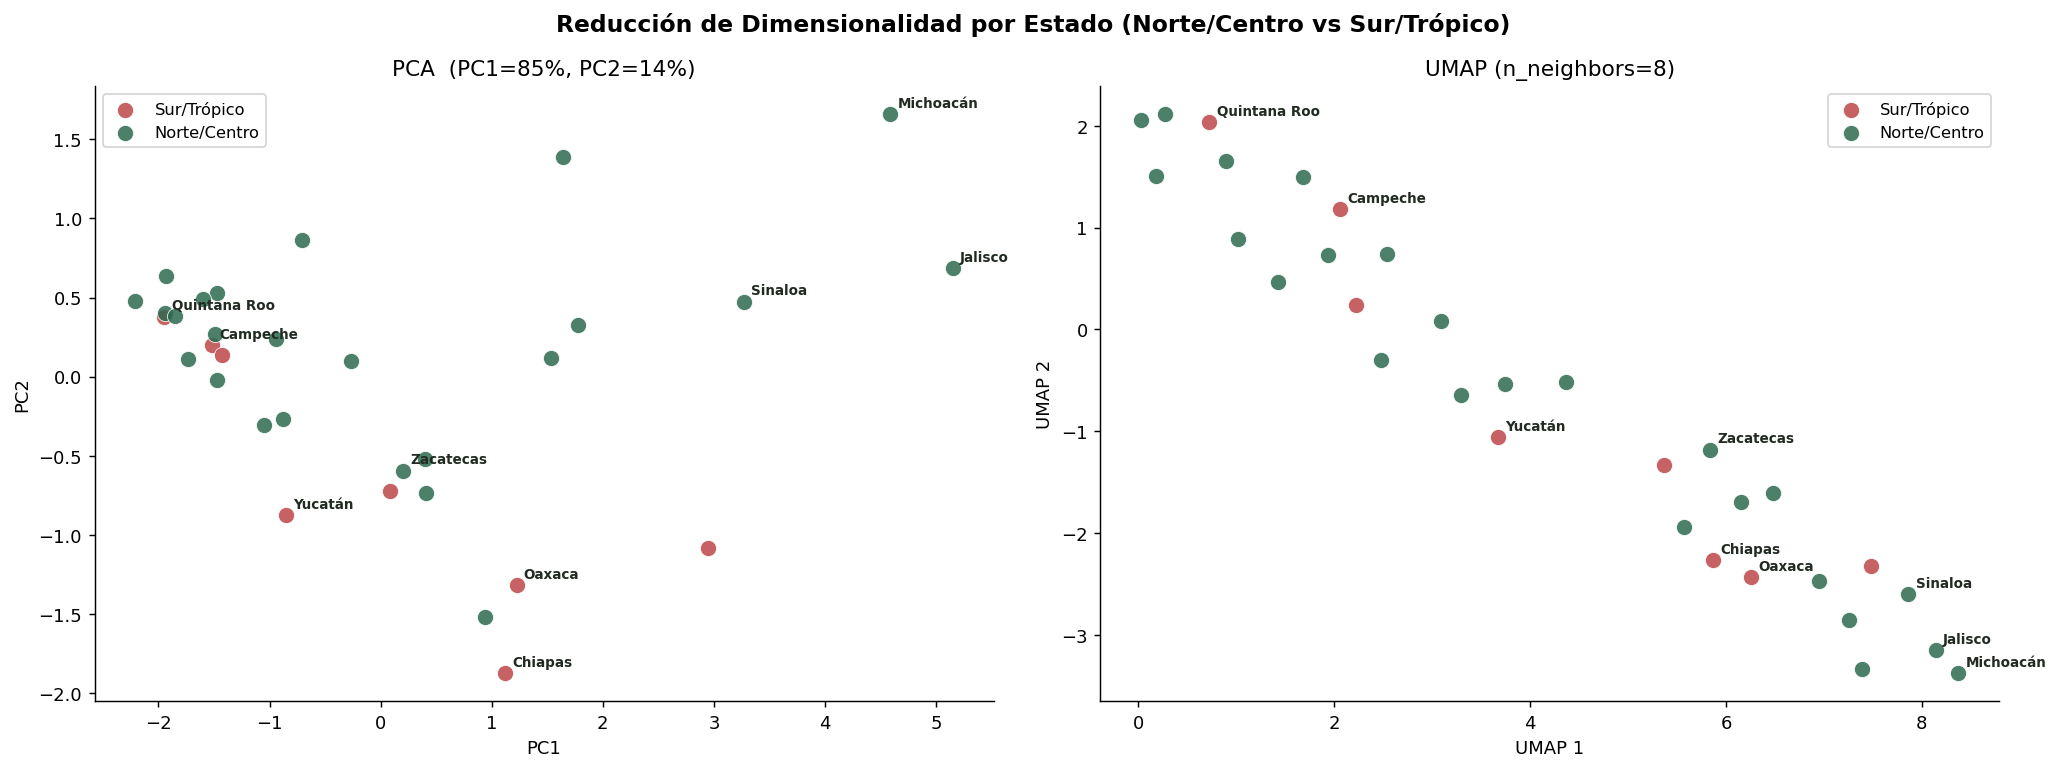

Cambio agrícola por estado (top ganadores y perdedores):
             estado       region  cambio_ha  cambio_pct
            Jalisco Norte/Centro  228497.12   15.792840
             Oaxaca  Sur/Trópico  177210.54   14.864586
           Campeche  Sur/Trópico  135913.58   65.538261
          Michoacán Norte/Centro  119797.06   11.098458
           Guerrero  Sur/Trópico  117290.99   14.555381
            Nayarit Norte/Centro   42204.28   12.480435
           Veracruz  Sur/Trópico   20910.54    1.367340
             Sonora Norte/Centro   16938.64    3.103139
       Quintana Roo  Sur/Trópico   16402.97   13.722916
             Colima Norte/Centro   14454.33    9.062197
            Morelos Norte/Centro    5592.36    4.090442
Baja California Sur Norte/Centro    4839.10   13.107077
           Tlaxcala Norte/Centro   -9506.32   -3.921215
   Ciudad de México Norte/Centro  -12424.50  -45.881063
          Chihuahua Norte/Centro  -28580.62   -2.808182
            Tabasco  Sur/Trópico  -48506.97  -1

In [14]:
# ── PCA sobre estados ─────────────────────────────────────────────────────────
pca_est = PCA(n_components=2, random_state=SEED)
X_pca_est = pca_est.fit_transform(X_est)
var_est = pca_est.explained_variance_ratio_

# UMAP sobre estados
umap_est = umap.UMAP(n_neighbors=8, min_dist=0.2, random_state=SEED, n_jobs=1)
X_umap_est = umap_est.fit_transform(X_est)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Reducción de Dimensionalidad por Estado (Norte/Centro vs Sur/Trópico)",
             fontsize=13, fontweight="bold")

ESTADOS_DESTACAR = [
    "Campeche","Chiapas","Oaxaca","Jalisco","Michoacán",
    "Quintana Roo","Zacatecas","Sinaloa","Yucatán"
]

for ax, X_plot, titl, x_lab, y_lab in [
    (axes[0], X_pca_est,  f"PCA  (PC1={var_est[0]*100:.0f}%, PC2={var_est[1]*100:.0f}%)",
     "PC1", "PC2"),
    (axes[1], X_umap_est, "UMAP (n_neighbors=8)", "UMAP 1", "UMAP 2"),
]:
    for region, color in {"Sur/Trópico": "#BC4749", "Norte/Centro": "#2D6A4F"}.items():
        mask = df_est["region"] == region
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=color, label=region, alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)

    for i, row in df_est.iterrows():
        if row["estado"] in ESTADOS_DESTACAR:
            ax.annotate(row["estado"], (X_plot[i, 0], X_plot[i, 1]),
                        fontsize=7.5, xytext=(4, 4), textcoords="offset points",
                        color="#212B22", fontweight="bold")

    ax.set_title(titl)
    ax.set_xlabel(x_lab)
    ax.set_ylabel(y_lab)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_output/DR_09_estados_pca_umap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cambio agrícola por estado (top ganadores y perdedores):")
print(df_est[["estado","region","cambio_ha","cambio_pct"]].sort_values(
    "cambio_ha", ascending=False).to_string(index=False))

---
## 9. Comparación de los 5 métodos

Un panel comparativo lado a lado con la configuración óptima de cada método.

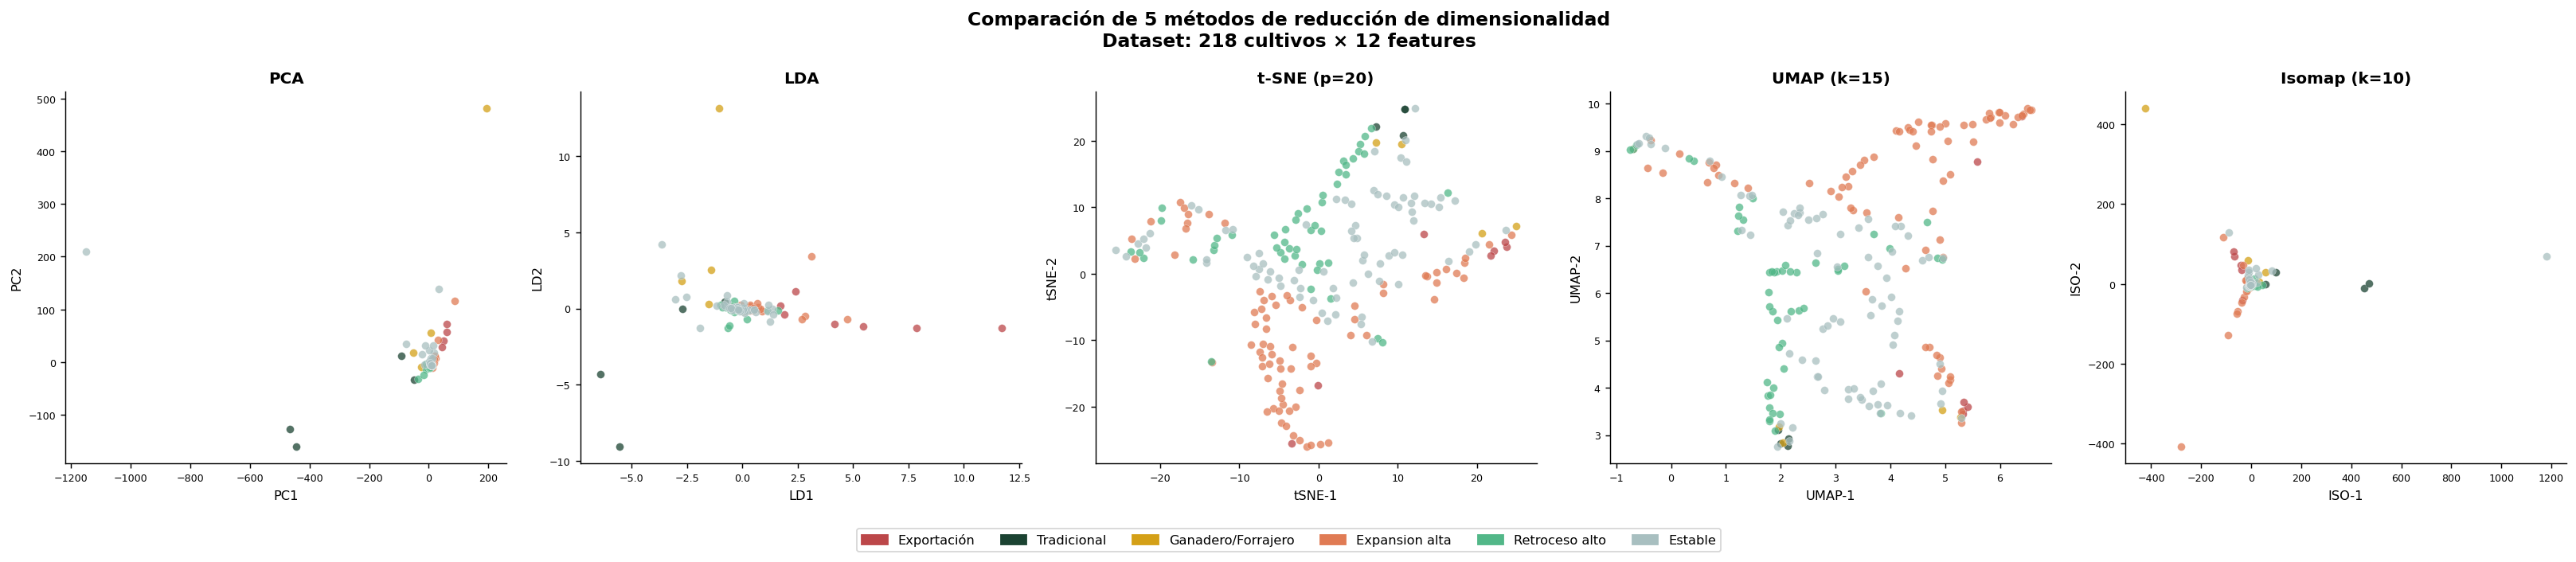

In [15]:
# ── Panel comparativo: los 5 métodos ─────────────────────────────────────────
metodos = [
    ("PCA",         X_pca,                "PC1",    "PC2"),
    ("LDA",         X_lda,                "LD1",    "LD2"),
    ("t-SNE (p=20)",X_tsne_best,          "tSNE-1", "tSNE-2"),
    ("UMAP (k=15)", X_umap_best,          "UMAP-1", "UMAP-2"),
    ("Isomap (k=10)",resultados_iso[10],  "ISO-1",  "ISO-2"),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(
    "Comparación de 5 métodos de reducción de dimensionalidad\nDataset: 218 cultivos × 12 features",
    fontsize=13, fontweight="bold"
)

for ax, (nombre, X_plot, xl, yl) in zip(axes, metodos):
    for cat, color in CAT_COLORS.items():
        mask = df_cult["categoria"] == cat
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=color, alpha=0.75, s=30,
                   edgecolors="white", linewidth=0.2, label=cat)
    ax.set_title(nombre, fontsize=11, fontweight="bold")
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.tick_params(labelsize=7)

# Leyenda compartida
handles = [mpatches.Patch(color=c, label=k) for k, c in CAT_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.08), framealpha=0.8)

plt.tight_layout()
plt.savefig("eda_output/DR_10_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Resumen y Conclusiones

### ¿Qué encontramos con cada técnica?

| Método | Tipo | Lo que reveló en este dataset |
|--------|------|-------------------------------|
| **PCA** | Lineal, no supervisado | PC1 captura la escala de producción (cultivos grandes vs. pequeños). PC2 diferencia cultivos en crecimiento vs. retroceso. Los cultivos de exportación y ganaderos quedan separados del grueso, pero hay solapamiento. Varianza capturada en 2D: ~60-70%. |
| **LDA** | Lineal, supervisado | Al usar las categorías como guía, logra separar mejor los grupos que PCA, especialmente entre cultivos de exportación y tradicionales. La separación no es perfecta porque las categorías tienen cierto solapamiento real. |
| **t-SNE** | No lineal, no supervisado | Revela clusters locales no visibles en PCA. Con perplexity=20, los cultivos de exportación forman un cluster compacto separado del grueso de cultivos estables. El gradiente de cambio_pct muestra claramente la zona de expansión. |
| **UMAP** | No lineal, no supervisado | Similar a t-SNE pero preserva mejor la estructura global. Los cultivos ganaderos/forrajeros quedan claramente aislados, reflejando que su perfil de valor por ha es bajo pero su expansión es masiva. Es el método más informativo para este dataset. |
| **Isomap** | No lineal, no supervisado | Captura la continuidad de la trayectoria: hay un continuo desde cultivos en colapso hasta cultivos en expansión explosiva. Con n_neighbors=10 produce la representación más suave y geométricamente interpretable. |

### Hallazgo transversal

En todos los métodos, **los cultivos de exportación (aguacate, agave, palma africana) y los cultivos ganaderos (pastos, maíz forrajero) se separan consistentemente del resto**. Esto confirma que su perfil multidimensional es estructuralmente distinto: no solo crecen en hectáreas, sino que lo hacen con una combinación de alto valor por ha (exportación) o escala masiva (ganadero) que los hace económicamente irresistibles para los productores, aunque su expansión ocurra en zonas de alta cobertura forestal.

### Relevancia para el proyecto

La reducción de dimensionalidad confirma visualmente lo que el EDA mostró numéricamente: **la transformación del campo mexicano no es aleatoria**. Los cultivos que más se expanden forman un cluster diferenciado tanto en tamaño como en valor, lo que los convierte en los candidatos más probables para correlacionar con pérdida forestal cuando se incorporen los datos completos de GFW por estado.

In [16]:
# ── Tabla resumen de métodos ──────────────────────────────────────────────────
resumen = pd.DataFrame([
    {"Método": "PCA",        "Tipo": "Lineal",    "Supervisado": "No",
     "Preserva": "Varianza global",   "Varianza 2D": f"{var_acum[1]*100:.1f}%",
     "Parámetro clave": "n_components"},
    {"Método": "LDA",        "Tipo": "Lineal",    "Supervisado": "Sí",
     "Preserva": "Separación de clases","Varianza 2D": "N/A",
     "Parámetro clave": "n_components"},
    {"Método": "t-SNE",      "Tipo": "No lineal", "Supervisado": "No",
     "Preserva": "Vecindad local",    "Varianza 2D": "N/A",
     "Parámetro clave": "perplexity"},
    {"Método": "UMAP",       "Tipo": "No lineal", "Supervisado": "No",
     "Preserva": "Local + global",    "Varianza 2D": "N/A",
     "Parámetro clave": "n_neighbors, min_dist"},
    {"Método": "Isomap",     "Tipo": "No lineal", "Supervisado": "No",
     "Preserva": "Geometría intrínseca","Varianza 2D": "N/A",
     "Parámetro clave": "n_neighbors"},
])
print(resumen.to_string(index=False))
print("\nArchivos generados en eda_output/:")
import glob
for f in sorted(glob.glob("eda_output/DR_*.png")):
    print(f"  {f}")

Método      Tipo Supervisado             Preserva Varianza 2D       Parámetro clave
   PCA    Lineal          No      Varianza global       93.5%          n_components
   LDA    Lineal          Sí Separación de clases         N/A          n_components
 t-SNE No lineal          No       Vecindad local         N/A            perplexity
  UMAP No lineal          No       Local + global         N/A n_neighbors, min_dist
Isomap No lineal          No Geometría intrínseca         N/A           n_neighbors

Archivos generados en eda_output/:
  eda_output\DR_01_pca_scree.png
  eda_output\DR_02_pca_biplot.png
  eda_output\DR_03_lda.png
  eda_output\DR_04_tsne_perplexity.png
  eda_output\DR_05_tsne_best.png
  eda_output\DR_06_umap_neighbors.png
  eda_output\DR_07_umap_best.png
  eda_output\DR_08_isomap.png
  eda_output\DR_09_estados_pca_umap.png
  eda_output\DR_10_comparacion.png
